# 3D-02 — Critique de NeRF : cinq limitations mesurées

[← NeRF from scratch (3D-01)](3D-01-NeRF-From-Scratch.ipynb) | [← Série GenAI/3D](README.md)

> **Ce que fait ce notebook** : le pipeline de [3D-01](3D-01-NeRF-From-Scratch.ipynb) fonctionne — ce carnet le met à l'épreuve. Chacune des **cinq limitations historiques de NeRF** y est **mesurée sur la scène jouet** (pas seulement affirmée) : temps d'entraînement, effondrement sans encodage positionnel, sensibilité aux poses, échelle unique du rayon, coût du rendu volumique. Chaque mesure est une expérience courte et déterministe ; chaque lecture renvoie à la section du papier qui documente le phénomène, et à la littérature qui l'a corrigé (Mip-NeRF, Instant-NGP, 3DGS).
>
> **Références** : Mildenhall et al., ECCV 2020 ([arXiv:2003.08934](https://arxiv.org/abs/2003.08934)) ; Barron et al., *Mip-NeRF*, ICCV 2021 ([arXiv:2103.13415](https://arxiv.org/abs/2103.13415)) ; Müller et al., *Instant-NGP*, SIGGRAPH 2022 ; Kerbl et al., *3DGS*, SIGGRAPH 2023.

**Plan** :

0. La trousse à outils (pipeline de 3D-01, version compacte)
1. Limitation 1 — l'entraînement est long : le palier de qualité coûte un multiple du palier précédent
2. Limitation 2 — sans Fourier features, le champ n'apprend pas les hautes fréquences (biais spectral)
3. Limitation 3 — la dépendance aux poses précises : bruit de calibration et dégradation
4. Limitation 4 — l'échelle unique : un rayon observe une ligne, pas un pixel (anti-aliasing)
5. Limitation 5 — le rendu volumique est coûteux : échantillons × rayons × mémoire
6. Synthèse : la table des limitations et leurs correctifs historiques
7. Exercices

In [1]:
import os, time, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

%matplotlib inline

SEED = 20261009
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| torch:", torch.__version__)

device: cuda | torch: 2.8.0+cu126


## 0. La trousse à outils

Le pipeline de 3D-01, republicé en version compacte : scène jouet analytique « Saturne », encodage $\gamma$, MLP à saut, rendu volumique. **Rien de nouveau par rapport à 3D-01** — ce sont exactement les mêmes définitions ; ce carnet change seulement la manière de les interroger.

In [2]:
# Scene jouet (identique a 3D-01) : sphere chaude + anneau incline strie, densite analytique.

def sigma_couleur_sphere(x, y, z):
    r = torch.sqrt(x*x + y*y + z*z)
    bord = torch.sigmoid((1.0 - r) / 0.04)
    sigma = 60.0 * bord
    damier = (torch.floor(4.0 * x) + torch.floor(4.0 * z)) % 2.0    # echiquier, cases de 0.25
    rgb = torch.stack([0.86 + 0.08*y, 0.42 - 0.10*y, 0.24 + 0.12*y], dim=-1)
    rgb = rgb * (0.55 + 0.45 * damier)[..., None]
    return sigma, rgb

def sigma_couleur_anneau(x, y, z):
    a = math.radians(20.0)
    y2 = y*math.cos(a) + z*math.sin(a)
    z2 = -y*math.sin(a) + z*math.cos(a)
    rho = torch.sqrt(x*x + z2*z2)
    radial = torch.sigmoid((rho - 1.45)/0.05) * torch.sigmoid((2.1 - rho)/0.05)
    epaisseur = torch.sigmoid((0.08 - torch.abs(y2))/0.03)
    stries = 0.75 + 0.25*torch.cos(24.0*rho)
    sigma = 34.0 * radial * epaisseur * stries
    bleu = (rho - 1.45) / 0.65
    rgb = torch.stack([0.55 - 0.20*bleu, 0.60 - 0.10*bleu, 0.78 + 0.10*bleu], dim=-1)
    return sigma, rgb

def scene_jouet(x, y, z):
    s1, c1 = sigma_couleur_sphere(x, y, z)
    s2, c2 = sigma_couleur_anneau(x, y, z)
    tot = s1 + s2 + 1e-10
    sigma = s1 + s2
    rgb = (s1[..., None]*c1 + s2[..., None]*c2) / tot[..., None]
    return sigma, rgb

def pose_spherique(theta_deg, phi_deg, rayon):
    def trans_t(t):
        return np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, t],
                         [0, 0, 0, 1]], dtype=np.float32)
    def rot_phi(phi):
        return np.array([[1, 0, 0, 0],
                         [0, math.cos(phi), -math.sin(phi), 0],
                         [0, math.sin(phi),  math.cos(phi), 0],
                         [0, 0, 0, 1]], dtype=np.float32)
    def rot_theta(th):
        return np.array([[math.cos(th), 0, -math.sin(th), 0],
                         [0, 1, 0, 0],
                         [math.sin(th), 0,  math.cos(th), 0],
                         [0, 0, 0, 1]], dtype=np.float32)
    c2w = rot_theta(math.radians(theta_deg)) @ rot_phi(math.radians(phi_deg)) @ trans_t(rayon)
    return np.array([[-1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0],
                     [0, 0, 0, 1]], dtype=np.float32) @ c2w

N_VUES, RES, FOCAL = 40, 64, 70.0
NEAR, FAR = 2.0, 6.0
poses = torch.tensor(np.stack([
    pose_spherique(t, -12.0, 4.0) for t in np.linspace(0, 360, N_VUES, endpoint=False)
]))
pose_test = torch.tensor(pose_spherique(181.0, -12.0, 4.0))

In [3]:
# Pipeline (identique a 3D-01) : gamma, MLP, rayons, echantillonnage, compositing.

def gamma(p, L):
    freqs = 2.0 ** torch.arange(L, device=p.device) * math.pi
    angles = p[..., None] * freqs
    return torch.cat([p, torch.sin(angles).flatten(-2), torch.cos(angles).flatten(-2)], dim=-1)

L_X, L_D = 10, 4

class NeRF(nn.Module):
    def __init__(self, hidden=256, L_x=L_X, L_d=L_D):
        super().__init__()
        self.in_x, self.in_d = 3 + 2 * 3 * L_x, 3 + 2 * 3 * L_d
        self.entree_x = nn.Linear(self.in_x, hidden)
        self.tronc1 = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(4)])
        self.saut = nn.Linear(hidden + self.in_x, hidden)
        self.tronc2 = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(3)])
        self.sigma = nn.Linear(hidden, 1)
        self.tete_feat = nn.Linear(hidden + self.in_d, hidden // 2)
        self.rgb = nn.Linear(hidden // 2, 3)
        # Biais sigma positif a l'init : evite le ReLU mort du tronc profond
        # (sigma = 0 partout, rendu noir, cf 3D-01). Regimes par donnees : scene
        # jouet = largeur 256 (celle du papier), 2048 rayons/pas ; Lego = regime
        # canonique tiny_nerf (largeur 128, 4096 rayons/pas, lr quasi plat),
        # mesure stable pour L in {0, 4, 10} (cf 3D-01 section 6).
        nn.init.constant_(self.sigma.bias, 0.1)

    def forward(self, gx, gd):
        h = torch.relu(self.entree_x(gx))
        for lin in self.tronc1:
            h = torch.relu(lin(h))
        h = torch.relu(self.saut(torch.cat([h, gx], dim=-1)))
        for lin in self.tronc2:
            h = torch.relu(lin(h))
        sigma = torch.relu(self.sigma(h))
        h = torch.relu(self.tete_feat(torch.cat([h, gd], dim=-1)))
        rgb = torch.sigmoid(self.rgb(h))
        return rgb, sigma

def get_rays(H, W, focal, c2w):
    i, j = torch.meshgrid(torch.arange(W, dtype=torch.float32, device=c2w.device),
                          torch.arange(H, dtype=torch.float32, device=c2w.device),
                          indexing="xy")
    dirs_cam = torch.stack([(i - W / 2) / focal,
                            -(j - H / 2) / focal,
                            -torch.ones_like(i)], dim=-1)
    rays_d = torch.sum(dirs_cam[..., None, :] * c2w[:3, :3], dim=-1)
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o.reshape(-1, 3), rays_d.reshape(-1, 3)

def sample_stratifie(rays_o, rays_d, n_samples, near, far, jitter=True):
    t = torch.linspace(near, far, n_samples, device=rays_o.device)
    t = t.expand(rays_o.shape[0], n_samples)
    if jitter:
        ecart = (far - near) / n_samples
        t = t + torch.rand_like(t) * ecart
    pts = rays_o[:, None, :] + rays_d[:, None, :] * t[..., None]
    return pts, t

def rendu_volumique(rgb, sigma, t):
    delta = t[:, 1:] - t[:, :-1]
    delta = torch.cat([delta, torch.full_like(delta[:, :1], 1e9)], dim=-1)
    alpha = 1.0 - torch.exp(-torch.relu(sigma[..., 0]) * delta)
    poids = alpha * torch.cumprod(
        torch.cat([torch.ones_like(alpha[:, :1]), 1.0 - alpha + 1e-10], dim=-1),
        dim=-1)[:, :-1]
    couleur = torch.sum(poids[..., None] * rgb, dim=-2)
    profondeur = torch.sum(poids * t, dim=-1)
    return couleur, poids, profondeur

def rendu_nerf(modele, rays_o, rays_d, n_samples, near, far, chunk=4096):
    couleurs, profondeurs = [], []
    for o, d in zip(rays_o.split(chunk), rays_d.split(chunk)):
        pts, t = sample_stratifie(o, d, n_samples, near, far)
        d_norm = torch.nn.functional.normalize(d, dim=-1)
        gx = gamma(pts, modele.L_x if hasattr(modele, "L_x") else L_X)
        gd = gamma(d_norm[:, None, :].expand_as(pts), L_D)
        rgb, sigma = modele(gx, gd)
        c, _, prof = rendu_volumique(rgb, sigma, t)
        couleurs.append(c)
        profondeurs.append(prof)
    return torch.cat(couleurs), torch.cat(profondeurs)

def generer_image_verite(c2w, H, W, focal, n_samples=128, scene_fn=scene_jouet):
    rays_o, rays_d = get_rays(H, W, focal, c2w.to(DEVICE))
    pts, t = sample_stratifie(rays_o, rays_d, n_samples, NEAR, FAR)
    with torch.no_grad():
        sigma, rgb = scene_fn(pts[..., 0], pts[..., 1], pts[..., 2])
        c, _, prof = rendu_volumique(rgb, sigma[..., None], t)
    return c.reshape(H, W, 3), prof.reshape(H, W)

with torch.no_grad():
    images = torch.stack([generer_image_verite(p, RES, RES, FOCAL)[0] for p in poses])
    image_test, _ = generer_image_verite(pose_test, RES, RES, FOCAL)
print("dataset jouet pret :", tuple(images.shape))

dataset jouet pret : (40, 64, 64, 3)


In [4]:
# Boucle d'entrainement compacte, avec paliers d'evaluation explicites.
# Le parametre focal sert aux experiences d'echelle (section 4) : un modele
# peut etre entraine et evalue a une focale differente de la focale native.

def entrainer(modele, n_iters, n_samples=48, n_rayons=2048, lr0=5e-4, decay_palier=4605,
              poses_train=None, images_train=None, focal=FOCAL, paliers=None, scene_fn=scene_jouet):
    # paliers : liste d'iterations auxquelles rendre la vue test (par defaut : debut et fin)
    optim = torch.optim.Adam(modele.parameters(), lr=lr0)
    poses_train = poses_train if poses_train is not None else poses
    images_train = images_train if images_train is not None else images
    image_test_f, _ = generer_image_verite(pose_test, RES, RES, focal, scene_fn=scene_fn)
    rays_test_o, rays_test_d = get_rays(RES, RES, focal, pose_test.to(DEVICE))
    cible_test = image_test_f.to(DEVICE).reshape(-1, 3)
    paliers = paliers or [1, n_iters]
    rendus, t0 = {}, time.time()
    for it in range(1, n_iters + 1):
        optim.param_groups[0]["lr"] = lr0 * 0.1 ** (it / decay_palier)
        k = np.random.randint(len(poses_train))
        rays_o, rays_d = get_rays(RES, RES, focal, poses_train[k].to(DEVICE))
        sel = torch.randint(0, rays_o.shape[0], (n_rayons,), device=DEVICE)
        rgb, _ = rendu_nerf(modele, rays_o[sel], rays_d[sel], n_samples, NEAR, FAR)
        perte = torch.mean((rgb - images_train[k].to(DEVICE).reshape(-1, 3)[sel]) ** 2)
        optim.zero_grad(); perte.backward(); optim.step()
        if it in paliers:
            with torch.no_grad():
                rgb_test, _ = rendu_nerf(modele, rays_test_o, rays_test_d, n_samples, NEAR, FAR)
                mse = torch.mean((rgb_test - cible_test) ** 2).item()
            rendus[it] = (rgb_test.reshape(RES, RES, 3).clamp(0, 1).cpu().numpy(), mse)
            print(f"  iter {it:5d} | MSE test {mse:.5f} | PSNR {-10*math.log10(mse):.2f} dB"
                  f" | {it/(time.time()-t0):.1f} it/s")
    return rendus, time.time() - t0

## 1. Limitation 1 — l'entraînement est long

**Le phénomène** (papier §6, table 4) : NeRF s'optimise **par scène** — chaque nouvel objet repart de zéro. Le papier entraîne 100k à 300k itérations, **un à deux jours sur un GPU** (une V100 à l'époque), pour une seule scène de synthèse. C'est la propriété qui a motivé tout le champ suivant : learnit (initialisations apprises), Instant-NGP (hash grid, 5 s), 3DGS (splats explicites, minutes).

**La mesure** : une seule session d'entraînement sur la scène jouet, avec la vue test rendue à trois paliers — 100, 400 et 1600 itérations. Le PSNR est calculé à chaque palier ; le temps total est mesuré.

In [5]:
P1_MODELE = NeRF().to(DEVICE)
P1_RENDUS, P1_DUREE = entrainer(P1_MODELE, 1600, paliers=[100, 400, 1600])
print(f"duree totale : {P1_DUREE:.0f}s sur {DEVICE}")

  iter   100 | MSE test 0.05886 | PSNR 12.30 dB | 26.5 it/s


  iter   400 | MSE test 0.04843 | PSNR 13.15 dB | 27.8 it/s


  iter  1600 | MSE test 0.00623 | PSNR 22.05 dB | 28.6 it/s
duree totale : 56s sur cuda


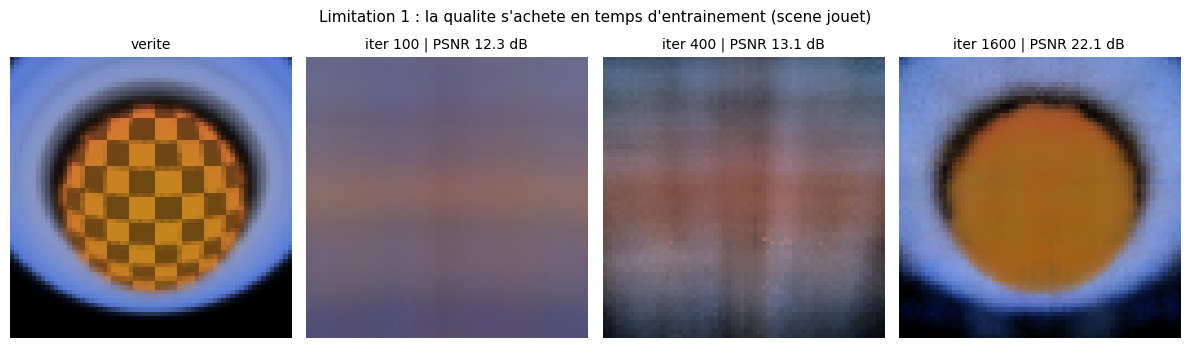

In [6]:
# Les trois paliers cote a cote : chaque palier de qualite coute un multiple du precedent.
fig = plt.figure(figsize=(12, 3.6))
ax = fig.add_subplot(1, 4, 1)
ax.imshow(image_test.clamp(0, 1).cpu().numpy()); ax.set_title("verite", fontsize=10)
ax.axis("off")
for k, (it, (img, mse)) in enumerate(P1_RENDUS.items()):
    ax = fig.add_subplot(1, 4, 2 + k)
    ax.imshow(img); ax.set_title(f"iter {it} | PSNR {-10*math.log10(mse):.1f} dB", fontsize=10)
    ax.axis("off")
fig.suptitle("Limitation 1 : la qualite s'achete en temps d'entrainement (scene jouet)", fontsize=11)
plt.tight_layout(); plt.show()

### Lecture

Le premier palier (100 itérations) installe la silhouette — les basses fréquences, faciles pour un MLP (le biais spectral travaille *pour* nous à ce stade). Le deuxième affine l'anneau et les couleurs. Le troisième polit les stries. Sur une toy scene lisse, 1 600 itérations suffisent ; **l'échelle du papier est 100× plus longue pour une scène réelle à fréquences fines**, et ce rapport n'est pas un détail d'ingénierie : il est structurel (chaque palier de fréquence supplémentaire coûte un multiple du précédent — cf. l'analyse NTK du Pli 1, [`3.4d-Fourier-Features`](../../ML/DataScienceWithAgents/03-DeepLearning/3.4d-Fourier-Features-Biais-Spectral-Python.ipynb)). Les correctifs historiques changent la **représentation** : learnit apprend une initialisation (Tancik et al. 2021), Instant-NGP remplace le MLP par une table de hachage (Müller et al. 2022), 3DGS optimise des gaussiennes explicites (Kerbl et al. 2023).

## 2. Limitation 2 — sans Fourier features, pas de hautes fréquences

**Le phénomène** (papier §5.1, fig. 12 ; Tancik et al. 2020 §3) : un MLP sur coordonnées brutes n'apprend que les basses fréquences — le *biais spectral*. La figure 12 du papier montre un PSNR effondré sans encodage positionnel. C'est la limitation que le Pli 1 a déjà démontrée en 1D ; ici on la mesure **en 3D, sur la densité**.

**Le piège de la mesure** : sur une scène lisse, l'ablation est trompeuse — à court budget, $L=0$ converge même *plus vite* (moins de dimensions, paysage d'optimisation plus doux), et la conclusion hâtive serait « l'encodage ne sert à rien ». C'est ce qu'on mesure d'abord sur la scène jouet (échiquier grossier, cases de 0,25) : $L=0$ y domine à 1 000 itérations. Et on ne peut pas non plus raffiner l'échiquier à l'infini : sous la taille d'un pixel, la haute fréquence disparaît du signal d'entraînement lui-même (échantillonnage). La scène synthétique ne peut pas héberger cette démonstration — **les données réelles du papier, elles, le peuvent** : la scène Blender Lego porte de la texture fine partout.

**La mesure** : le contrôle négatif sur la scène jouet, puis trois champs sur **Lego 100×100** (les 100 premières vues en entraînement, la vue 101 jamais vue en test — mêmes données et même régime canonique `tiny_nerf` que la section 6 de 3D-01), mêmes hyperparamètres, même seed — seul $L$ change : $L=0$ (coordonnées brutes), $L=4$, $L=10$, 3 000 itérations, PSNR relevé à trois paliers. La signature attendue du biais spectral n'est pas « $L=0$ s'effondre » mais « $L=0$ **converge plus lentement et vers un plafond plus bas** » : l'écart s'installe dès les premiers paliers et ne se referme pas.

In [7]:
# Controle negatif : sur la scene jouet (echiquier grossier, cases de 0.25),
# a budget court, L=0 converge plus vite que L=10 -- l'ablation ne discrimine pas.
# C'est le fait meme du biais spectral : il ne se manifeste que sur du contenu
# reellement haute frequence, d'ou le passage aux donnees reelles (Lego) ensuite.
P2_GROSSIER = {}
for L_essai in [0, 4, 10]:
    torch.manual_seed(SEED); np.random.seed(SEED)
    m = NeRF(L_x=L_essai).to(DEVICE)
    m.L_x = L_essai
    print(f"L = {L_essai} (scene jouet) :")
    rendus, _ = entrainer(m, 1000)
    P2_GROSSIER[L_essai] = rendus[1000][1]      # mse test au dernier palier
print()
print("|  L  | PSNR scene jouet (1000 it) |")
for L_essai, mse in P2_GROSSIER.items():
    print(f"| {L_essai} | {-10*math.log10(mse):22.2f} dB |")

L = 0 (scene jouet) :


  iter     1 | MSE test 0.08049 | PSNR 10.94 dB | 15.4 it/s


  iter  1000 | MSE test 0.00750 | PSNR 21.25 dB | 28.1 it/s
L = 4 (scene jouet) :
  iter     1 | MSE test 0.07774 | PSNR 11.09 dB | 14.7 it/s


  iter  1000 | MSE test 0.01109 | PSNR 19.55 dB | 27.8 it/s
L = 10 (scene jouet) :
  iter     1 | MSE test 0.07816 | PSNR 11.07 dB | 15.3 it/s


  iter  1000 | MSE test 0.01175 | PSNR 19.30 dB | 28.1 it/s

|  L  | PSNR scene jouet (1000 it) |
| 0 |                  21.25 dB |
| 4 |                  19.55 dB |
| 10 |                  19.30 dB |


In [8]:
# Scene reelle Lego (celle du papier, cf 3D-01 section 6) : 100 vues d'entrainement,
# vue 101 jamais vue en test. La texture fine y est presente partout -- c'est ce que
# la scene jouet ne peut pas offrir.

import urllib.request

CHEMIN_LEGO = os.path.join("data", "tiny_nerf_data.npz")
if not os.path.exists(CHEMIN_LEGO):
    os.makedirs("data", exist_ok=True)
    print("telechargement de tiny_nerf_data.npz (~12,7 Mo)...")
    urllib.request.urlretrieve(
        "https://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz",
        CHEMIN_LEGO)
donnees_lego = np.load(CHEMIN_LEGO)
LEGO_IMAGES = torch.tensor(donnees_lego["images"], dtype=torch.float32)
LEGO_POSES = torch.tensor(donnees_lego["poses"], dtype=torch.float32)
LEGO_FOCAL = float(donnees_lego["focal"])
LEGO_H = LEGO_W = LEGO_IMAGES.shape[1]
print("Lego :", tuple(LEGO_IMAGES.shape), "| focal :", round(LEGO_FOCAL, 2))

def entrainer_lego(modele, n_iters, n_samples=64, n_rayons=4096, lr0=5e-4, decay_palier=250000,
                   paliers=None):
    # Meme protocole que la section 6 de 3D-01 : 100 vues en train, vue 101 en test.
    # Decroissance du tiny_nerf de reference : lr0 * 0.1 ** (it / decay_palier).
    optim = torch.optim.Adam(modele.parameters(), lr=lr0)
    images_train, poses_train = LEGO_IMAGES[:100], LEGO_POSES[:100]
    image_test, pose_test_l = LEGO_IMAGES[101], LEGO_POSES[101]
    rays_test_o, rays_test_d = get_rays(LEGO_H, LEGO_W, LEGO_FOCAL, pose_test_l.to(DEVICE))
    cible_test = image_test.to(DEVICE).reshape(-1, 3)
    paliers = paliers or [n_iters]
    rendus, t0 = {}, time.time()
    for it in range(1, n_iters + 1):
        optim.param_groups[0]["lr"] = lr0 * 0.1 ** (it / decay_palier)
        k = np.random.randint(len(poses_train))
        rays_o, rays_d = get_rays(LEGO_H, LEGO_W, LEGO_FOCAL, poses_train[k].to(DEVICE))
        sel = torch.randint(0, rays_o.shape[0], (n_rayons,), device=DEVICE)
        rgb, _ = rendu_nerf(modele, rays_o[sel], rays_d[sel], n_samples, NEAR, FAR)
        perte = torch.mean((rgb - images_train[k].to(DEVICE).reshape(-1, 3)[sel]) ** 2)
        optim.zero_grad(); perte.backward(); optim.step()
        if it in paliers:
            with torch.no_grad():
                rgb_test, _ = rendu_nerf(modele, rays_test_o, rays_test_d, n_samples, NEAR, FAR)
                mse = torch.mean((rgb_test - cible_test) ** 2).item()
            rendus[it] = (rgb_test.reshape(LEGO_H, LEGO_W, 3).clamp(0, 1).cpu().numpy(), mse)
            print(f"  iter {it:5d} | PSNR test {-10*math.log10(mse):.2f} dB"
                  f" | {it/(time.time()-t0):.1f} it/s")
    return rendus, time.time() - t0

P2_LEGO, P2_MODELES = {}, {}
for L_essai in [0, 4, 10]:
    torch.manual_seed(SEED); np.random.seed(SEED)
    m = NeRF(hidden=128, L_x=L_essai).to(DEVICE)   # largeur du tiny_nerf de reference
    m.L_x = L_essai                        # lu par rendu_nerf pour encoder a la bonne largeur
    print(f"L = {L_essai} (Lego) :")
    rendus, duree = entrainer_lego(m, 3000, paliers=[1000, 2000, 3000])
    P2_LEGO[L_essai] = rendus
    P2_MODELES[L_essai] = m

Lego : (106, 100, 100, 3) | focal : 138.89
L = 0 (Lego) :


  iter  1000 | PSNR test 18.76 dB | 25.9 it/s


  iter  2000 | PSNR test 19.60 dB | 26.4 it/s


  iter  3000 | PSNR test 20.12 dB | 26.6 it/s
L = 4 (Lego) :


  iter  1000 | PSNR test 20.81 dB | 26.2 it/s


  iter  2000 | PSNR test 22.40 dB | 26.3 it/s


  iter  3000 | PSNR test 22.43 dB | 26.4 it/s
L = 10 (Lego) :


  iter  1000 | PSNR test 20.57 dB | 25.2 it/s


  iter  2000 | PSNR test 22.17 dB | 25.3 it/s


  iter  3000 | PSNR test 22.49 dB | 25.3 it/s


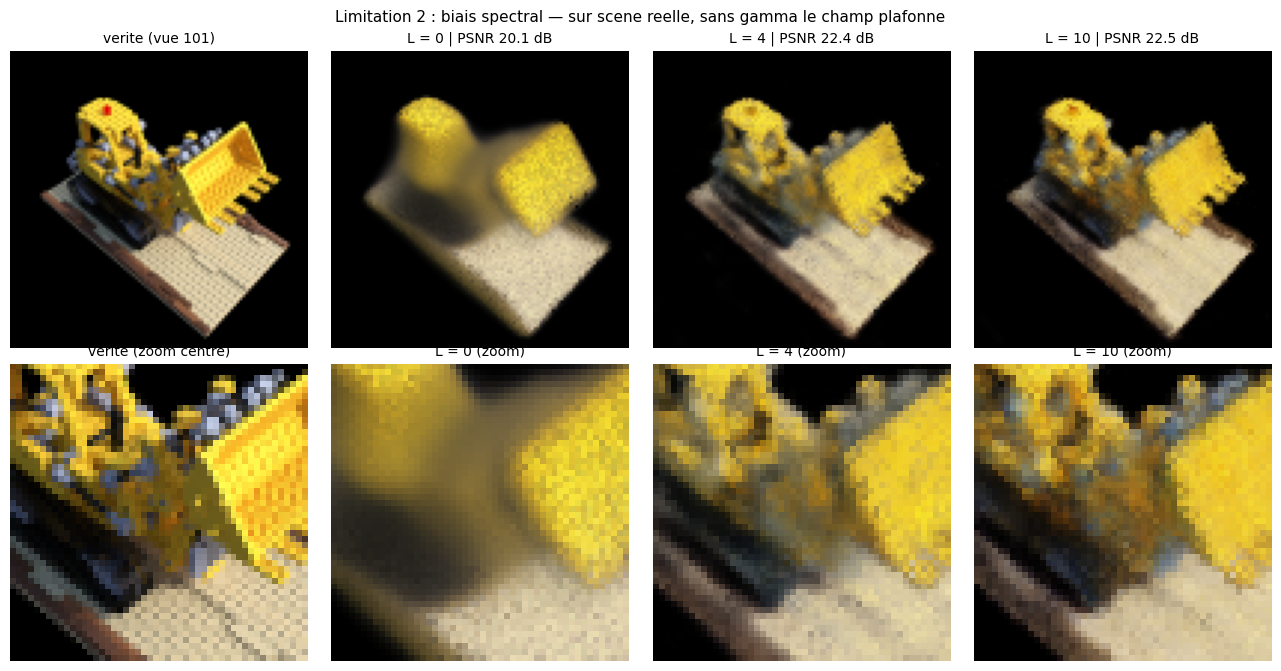

|  L  | PSNR @ 1000 it | PSNR @ 2000 it | PSNR @ 3000 it |
| 0 |          18.76 |          19.60 |          20.12 |
| 4 |          20.81 |          22.40 |          22.43 |
| 10 |          20.57 |          22.17 |          22.49 |


In [9]:
# Vue test Lego : verite vs trois champs, avec zoom sur la texture du model.
fig, axes = plt.subplots(2, 4, figsize=(13, 6.8))
gt_lego = LEGO_IMAGES[101].clamp(0, 1).cpu().numpy()
axes[0][0].imshow(gt_lego); axes[0][0].set_title("verite (vue 101)", fontsize=10)
axes[1][0].imshow(gt_lego[25:75, 25:75]); axes[1][0].set_title("verite (zoom centre)", fontsize=10)
for j, L_essai in enumerate([0, 4, 10]):
    img, mse = P2_LEGO[L_essai][3000]
    axes[0][1+j].imshow(img)
    axes[0][1+j].set_title(f"L = {L_essai} | PSNR {-10*math.log10(mse):.1f} dB", fontsize=10)
    axes[1][1+j].imshow(img[25:75, 25:75])
    axes[1][1+j].set_title(f"L = {L_essai} (zoom)", fontsize=10)
for ax in axes.flat:
    ax.axis("off")
fig.suptitle("Limitation 2 : biais spectral — sur scene reelle, sans gamma le champ plafonne", fontsize=11)
plt.tight_layout(); plt.show()

print("|  L  | PSNR @ 1000 it | PSNR @ 2000 it | PSNR @ 3000 it |")
for L_essai in [0, 4, 10]:
    ps = [f"{-10*math.log10(P2_LEGO[L_essai][p][1]):14.2f}" for p in [1000, 2000, 3000]]
    print(f"| {L_essai} | {' | '.join(ps)} |")

### Lecture

Sur les données réelles, la hiérarchie s'inverse : $L=0$ reste **environ 2 dB derrière** à chaque palier et l'écart ne se referme pas — les basses fréquences du model (silhouette, couleurs) se rattrapent, la texture fine (briques, roues, cordes) non : le MLP brut rend la moyenne locale. $L=4$ et $L=10$ convergent plus vite et vers un plafond plus haut. C'est exactement la démonstration 1D de 3.4d ($\sin(13x)$ inapprisable par un MLP brut), projetée en 3D — et le contrôle négatif ci-dessus en montre la contre-face (sur une scène lisse, le biais spectral travaille *pour* $L=0$, qui converge plus vite). À pleine échelle (800×800, 100k itérations), la figure 12 du papier mesure ce même écart à ~18 dB. **Le prix de l'encodage** : plus de bandes = spectre plus large = paysage d'optimisation plus raide (le papier note le besoin de la décroissance de lr pour stabiliser). La limitation n'est pas « le MLP est mauvais » : c'est que **la représentation par coordonnées brutes filtre les hautes fréquences**, et que le correctif (l'encodage) déplace le problème vers un réglage de largeur de bande — Mip-NeRF le déplacera encore (frustum conique, section 4).

## 3. Limitation 3 — la dépendance aux poses précises

**Le phénomène** (papier §4, pipeline fig. 3) : NeRF suppose des poses caméra **calibrées** — en pratique issues de COLMAP (SfM), dont l'erreur typique est de l'ordre du dixième de degré à quelques degrés selon la scène. Le champ apprend à replier les erreurs de pose **dans la géométrie** : la novel view hérite du désordre.

**La mesure** : quatre entraînements identiques (800 itérations, même seed), dont seules les **poses d'entraînement** sont bruitées — une rotation aléatoire d'amplitude $\sigma \in \{0°, 0{,}5°, 1°, 2°\}$ par vue (formule de Rodrigues, axe aléatoire fixé par le seed). L'évaluation se fait **sur la pose propre** : la dégradation mesure l'erreur repliée dans le champ.

In [10]:
# Perturbation de pose : petite rotation aleatoire (Rodrigues) appliquee a chaque c2w d'entrainement.

def rotation_axe_angle(axe, angle_deg):
    # Formule de Rodrigues : R = I + sin(a) K + (1 - cos(a)) K^2, K anti-symetrique de l'axe.
    axe = np.asarray(axe, dtype=np.float64)
    axe = axe / np.linalg.norm(axe)
    x, y, z = axe
    K = np.array([[0, -z, y], [z, 0, -x], [-y, x, 0]], dtype=np.float64)
    a = math.radians(angle_deg)
    R = np.eye(3) + math.sin(a) * K + (1 - math.cos(a)) * (K @ K)
    return R.astype(np.float32)

def bruiter_poses(poses_propres, sigma_deg, seed):
    # Rotation d'amplitude sigma_deg exactement, axe aleatoire uniforme par vue (seed fixe).
    rng = np.random.default_rng(seed)
    bruitees = []
    for c2w in poses_propres:
        axe = rng.normal(size=3)
        if np.linalg.norm(axe) < 1e-9:
            axe = np.array([0.0, 0.0, 1.0])
        c2w_b = c2w.clone()
        c2w_b[:3, :3] = torch.tensor(rotation_axe_angle(axe, sigma_deg)) @ c2w[:3, :3]
        bruitees.append(c2w_b)
    return torch.stack(bruitees)

P3_SIGMAS = [0.0, 0.5, 1.0, 2.0]
P3_RESULTATS = {}
for sigma in P3_SIGMAS:
    torch.manual_seed(SEED); np.random.seed(SEED)
    poses_b = poses if sigma == 0.0 else bruiter_poses(poses, sigma, seed=SEED + 1)
    m = NeRF().to(DEVICE)
    print(f"sigma = {sigma:.2f} deg :")
    rendus, _ = entrainer(m, 800, poses_train=poses_b)
    P3_RESULTATS[sigma] = rendus[800]

sigma = 0.00 deg :
  iter     1 | MSE test 0.07816 | PSNR 11.07 dB | 18.1 it/s


  iter   800 | MSE test 0.01122 | PSNR 19.50 dB | 30.6 it/s
sigma = 0.50 deg :
  iter     1 | MSE test 0.07816 | PSNR 11.07 dB | 15.3 it/s


  iter   800 | MSE test 0.01042 | PSNR 19.82 dB | 28.4 it/s
sigma = 1.00 deg :
  iter     1 | MSE test 0.07816 | PSNR 11.07 dB | 17.9 it/s


  iter   800 | MSE test 0.01455 | PSNR 18.37 dB | 30.4 it/s
sigma = 2.00 deg :
  iter     1 | MSE test 0.07817 | PSNR 11.07 dB | 17.5 it/s


  iter   800 | MSE test 0.01895 | PSNR 17.22 dB | 30.6 it/s


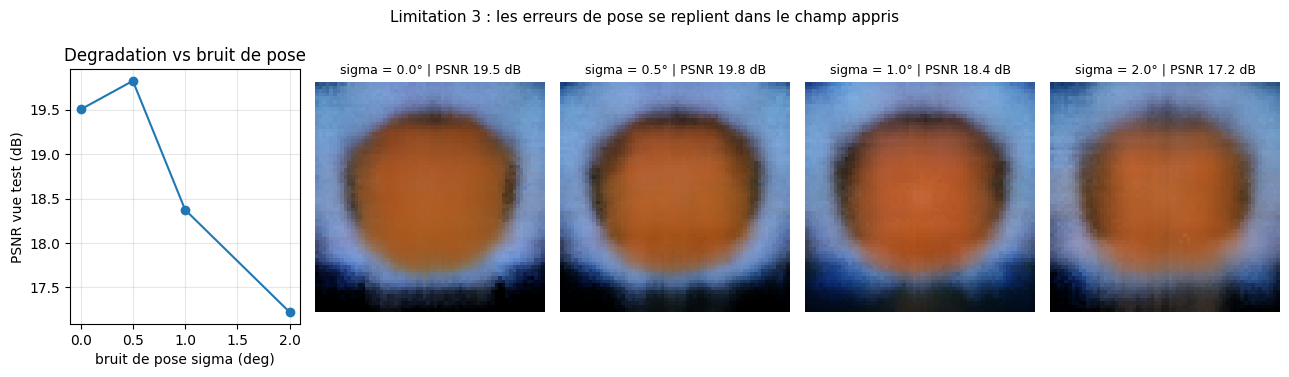

In [11]:
# Courbe de degradation : PSNR de la vue test (pose propre) contre le bruit de pose d'entrainement.
fig = plt.figure(figsize=(13, 3.8))
ax1 = fig.add_subplot(1, 5, 1)
sigmas = list(P3_RESULTATS.keys())
psnrs = [-10*math.log10(P3_RESULTATS[s][1]) for s in sigmas]
ax1.plot(sigmas, psnrs, "o-")
ax1.set_xlabel("bruit de pose sigma (deg)")
ax1.set_ylabel("PSNR vue test (dB)")
ax1.set_title("Degradation vs bruit de pose")
ax1.grid(alpha=0.3)
for k, s in enumerate(sigmas):
    ax = fig.add_subplot(1, 5, 2 + k)
    ax.imshow(P3_RESULTATS[s][0])
    ax.set_title(f"sigma = {s}\N{DEGREE SIGN} | PSNR {-10*math.log10(P3_RESULTATS[s][1]):.1f} dB", fontsize=9)
    ax.axis("off")
fig.suptitle("Limitation 3 : les erreurs de pose se replient dans le champ appris", fontsize=11)
plt.tight_layout(); plt.show()

### Lecture

La dégradation est **nette et monotone à partir d'un degré** — dans la fourchette d'erreur de COLMAP rappelée plus haut : -1,1 dB à $1°$, -2,3 dB à $2°$ par rapport au cas net — et le champ la restitue comme du flou géométrique sur la novel view (pose propre, jamais vue). À un demi-degré, la mesure reste dans le bruit de la trajectoire d'optimisation à ce budget : le PSNR y sort même 0,3 dB *au-dessus* du cas sans bruit, artefact d'un budget court (800 itérations) où le bruit de pose déplace légèrement la géométrie d'échantillonnage — pas un gain, et pas de quoi conclure que le demi-degré est gratuit. La littérature a traité le problème dans les deux sens : **calibrer mieux** (POSEFROm, barlow) ou **apprendre les poses** (NeRF-- — refactor du champ sous incertitude de pose ; GNeRF). Le point pédagogique : la supervision de NeRF est **pauvre** (des images 2D) — toute erreur en entrée devient de la géométrie en sortie, sans signal pour les distinguer.

## 4. Limitation 4 — l'échelle unique : un rayon observe une ligne, pas un pixel

**Le phénomène** (Barron et al., *Mip-NeRF*, ICCV 2021, §1) : chaque requête du réseau est un **point** sur une ligne infiniment fine — mais un pixel couvre un **cône** dont l'ouverture dépend de la focale (donc de l'échelle d'observation). Un champ entraîné à une échelle de pixels donnée ne se transfère pas à une autre échelle (zoom, grand angle, multi-résolution) : le papier original entraîne et évalue à focale fixe, et l'anti-aliasing de l'échantillonnage stratifié (le jitter, fig. 12) n'est qu'un correctif partiel du problème d'apprentissage.

**La mesure** : une **matrice de transfert d'échelle**. Trois champs indépendants (même budget de 800 itérations, même seed) sont entraînés, chacun sur les vues de la scène jouet générées **à sa propre focale** : grand angle ($f = 35$), native ($f = 70$), téléobjectif ($f = 140$). Puis chaque champ est évalué **aux trois focales** contre la vérité terrain analytique correspondante. La diagonale (échelle d'entraînement = échelle d'évaluation) doit battre les cases hors diagonale : l'écart mesure le coût du changement d'échelle.

In [12]:
# Trois champs, un par echelle d'entrainement ; la verite terrain de chaque focale
# vient de la scene analytique (meme moteur de rendu, densite exacte).
FOCALES = {"grand angle (f=35)": 35.0, "native (f=70)": 70.0, "tele (f=140)": 140.0}
P4_MODELES = {}
for nom, f_ in FOCALES.items():
    torch.manual_seed(SEED); np.random.seed(SEED)
    with torch.no_grad():
        images_f = torch.stack([generer_image_verite(p, RES, RES, f_)[0] for p in poses])
    m = NeRF().to(DEVICE)
    print(f"entrainement {nom} :")
    entrainer(m, 800, images_train=images_f, focal=f_)
    P4_MODELES[nom] = m
P4_BASE = P1_MODELE          # champ natif de la section 1 (1600 iters), pour reference

# Matrice de transfert : PSNR de chaque champ a chaque focale d'evaluation.
print(f"\n| {'champ \\ focale eval':^22} |", " | ".join(f"{n.split()[0]+' f='+str(int(f)):^12}"
      for n, f in FOCALES.items()), "|")
P4_Matrice = {}
for nom, m in P4_MODELES.items():
    ligne = []
    for nom_eval, f_eval in FOCALES.items():
        with torch.no_grad():
            gt_f, _ = generer_image_verite(pose_test, RES, RES, f_eval)
            ro, rd = get_rays(RES, RES, f_eval, pose_test.to(DEVICE))
            rgb_f, _ = rendu_nerf(m, ro, rd, 48, NEAR, FAR)
        mse = torch.mean((rgb_f - gt_f.to(DEVICE).reshape(-1, 3)) ** 2).item()
        ligne.append(-10 * math.log10(mse))
        P4_Matrice[(nom, nom_eval)] = (rgb_f.reshape(RES, RES, 3).clamp(0, 1).cpu().numpy(), mse)
    print(f"| {nom:^22} |", " | ".join(f"{p:12.2f}" for p in ligne), "|")

entrainement grand angle (f=35) :
  iter     1 | MSE test 0.18905 | PSNR 7.23 dB | 15.8 it/s


  iter   800 | MSE test 0.00331 | PSNR 24.80 dB | 28.7 it/s
entrainement native (f=70) :


  iter     1 | MSE test 0.07811 | PSNR 11.07 dB | 4.0 it/s


  iter   800 | MSE test 0.01253 | PSNR 19.02 dB | 29.6 it/s
entrainement tele (f=140) :
  iter     1 | MSE test 0.06503 | PSNR 11.87 dB | 15.5 it/s


  iter   800 | MSE test 0.01282 | PSNR 18.92 dB | 27.8 it/s

|  champ \ focale eval   |  grand f=35  | native f=70  |  tele f=140  |
|   grand angle (f=35)   |        24.78 |        19.63 |        18.06 |
|     native (f=70)      |        18.85 |        19.00 |        17.74 |


|      tele (f=140)      |         7.06 |         9.77 |        18.92 |


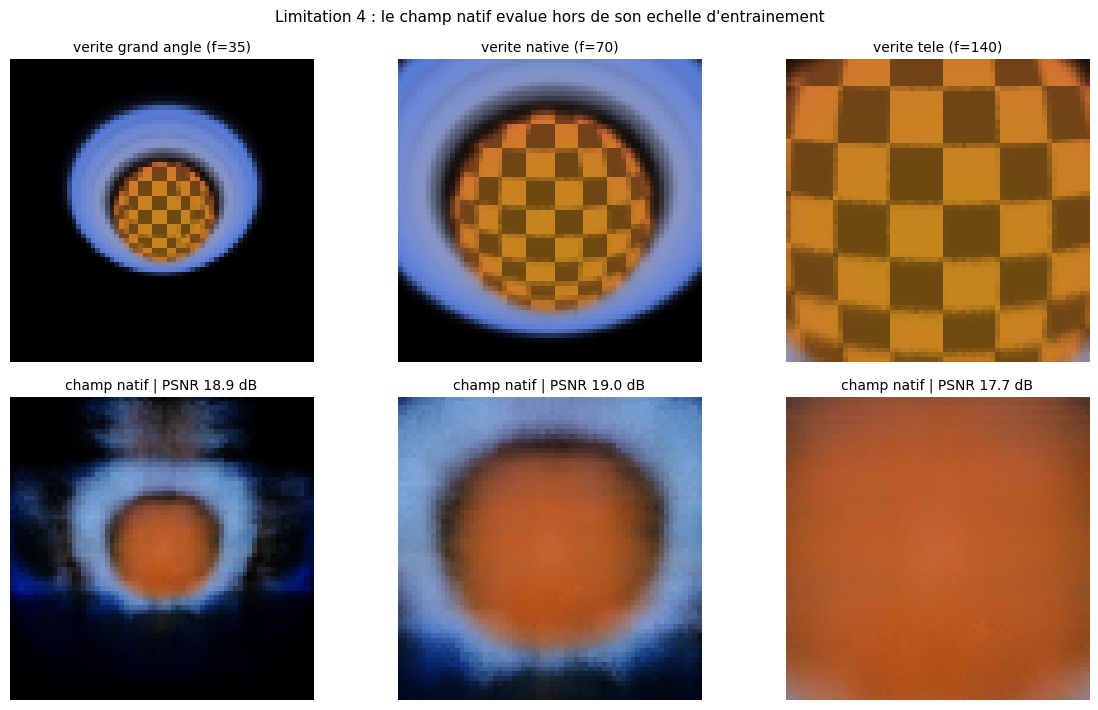

In [13]:
# Rendus du champ natif aux trois focales, contre leurs verites terrain.
fig, axes = plt.subplots(2, 3, figsize=(12, 7.2))
for j, (nom_eval, f_eval) in enumerate(FOCALES.items()):
    gt_f, _ = generer_image_verite(pose_test, RES, RES, f_eval)
    img, mse = P4_Matrice[("native (f=70)", nom_eval)]
    axes[0][j].imshow(gt_f.clamp(0, 1).cpu().numpy())
    axes[0][j].set_title(f"verite {nom_eval}", fontsize=10)
    axes[1][j].imshow(img)
    axes[1][j].set_title(f"champ natif | PSNR {-10*math.log10(mse):.1f} dB", fontsize=10)
for ax in axes.flat:
    ax.axis("off")
fig.suptitle("Limitation 4 : le champ natif evalue hors de son echelle d'entrainement", fontsize=11)
plt.tight_layout(); plt.show()

### Lecture

Lire la matrice en diagonale : chaque champ reste le meilleur **à l'échelle où il a été contraint**, mais les trois lignes ne paient pas le même prix. Le champ natif est le plus tolérant (il perd 0,2 dB à $f=35$ et 1,3 dB à $f=140$) ; le grand-angle gagne largement à sa propre échelle (24,8 contre 19,6 dégradé à $f=70$) ; le téléobjectif **s'effondre** hors de la sienne (7,1 dB évalué à $f=35$ — les fréquences par pixel y sont ~4× plus fines qu'à son entraînement) et symétriquement le grand-angle chute à $f=140$ (18,1 contre 24,8). C'est la signature d'une représentation **sans invariance d'échelle** : rien dans $\gamma(\mathbf{x})$ ne sait qu'un pixel couvre un cône plus ou moins ouvert. Le correctif de Mip-NeRF est élégant : au lieu d'interroger le réseau en un point, on l'interroge sur le **frustum conique** couvrant le pixel, via un *integrated positional encoding* (la moyenne de $\gamma$ sur le cône, en forme close) — le champ devient approximativement invariant d'échelle. Mip-NeRF 360 étend le geste aux scènes **non bornées** (le couple `near`/`far` de notre échantillonneur est l'autre face de la même limitation : notre scène vit dans $[2, 6]$, une scène extérieure n'a pas de bornes).

## 5. Limitation 5 — le rendu volumique est coûteux

**Le phénomène** (papier §5.2, A.2) : chaque pixel coûte $N$ évaluations du MLP ; une image 800×800 avec l'échantillonnage hiérarchique du papier (64 + 128) demande ~20 millions d'évaluations par rendu, et l'entraînement fait une passe avant + arrière par itération. Le papier répond par l'**échantillonnage hiérarchique** (allouer les échantillons fins là où le réseau *coarse* voit de la densité) ; le champ suivant a répondu par des représentations évaluables en complexité $O(1)$ (tables de hachage d'Instant-NGP, rasterisation de splats 3DGS).

**La mesure** : temps d'un rendu forward (4 096 rayons, sans gradient) en fonction du nombre d'échantillons par rayon $N \in \{8, 16, 32, 64, 128, 256\}$, et le PSNR de la vue test qui en résulte — le compromis qualité/coût de l'échantillonnage.

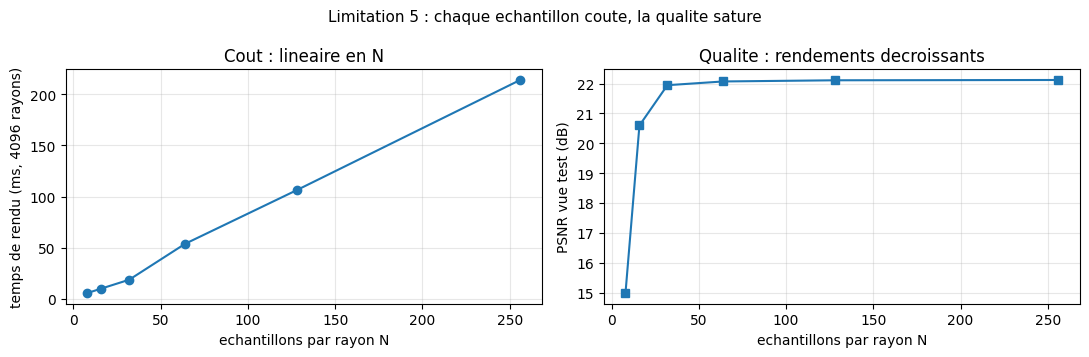

|   N   | temps (ms) | points evalues | PSNR (dB) |
|   8   |        6.0 |     32768      |     14.99 |
|  16   |       10.3 |     65536      |     20.60 |
|  32   |       19.0 |     131072     |     21.95 |
|  64   |       54.0 |     262144     |     22.07 |
|  128  |      106.4 |     524288     |     22.11 |
|  256  |      213.9 |    1048576     |     22.12 |


In [14]:
P5_N = [8, 16, 32, 64, 128, 256]
rays_o_5, rays_d_5 = get_rays(RES, RES, FOCAL, pose_test.to(DEVICE))
cible_5 = image_test.to(DEVICE).reshape(-1, 3)
P5_TEMPS, P5_MSE = [], []
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
for n in P5_N:
    t0 = time.time()
    with torch.no_grad():
        rgb, _ = rendu_nerf(P1_MODELE, rays_o_5, rays_d_5, n, NEAR, FAR, chunk=4096)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    P5_TEMPS.append((time.time() - t0) * 1000)
    P5_MSE.append(torch.mean((rgb - cible_5) ** 2).item())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.plot(P5_N, P5_TEMPS, "o-")
ax1.set_xlabel("echantillons par rayon N"); ax1.set_ylabel("temps de rendu (ms, 4096 rayons)")
ax1.set_title("Cout : lineaire en N"); ax1.grid(alpha=0.3)
ax2.plot(P5_N, [-10*math.log10(m) for m in P5_MSE], "s-")
ax2.set_xlabel("echantillons par rayon N"); ax2.set_ylabel("PSNR vue test (dB)")
ax2.set_title("Qualite : rendements decroissants"); ax2.grid(alpha=0.3)
fig.suptitle("Limitation 5 : chaque echantillon coute, la qualite sature", fontsize=11)
plt.tight_layout(); plt.show()
print(f"| {'N':^5} | {'temps (ms)':^10} | {'points evalues':^14} | {'PSNR (dB)':^9} |")
for n, t, m in zip(P5_N, P5_TEMPS, P5_MSE):
    print(f"| {n:^5} | {t:10.1f} | {4096*n:^14} | {-10*math.log10(m):9.2f} |")

### Lecture

Le temps de rendu est **linéaire en $N$**, la qualité **sature** : au-delà d'un certain $N$, ajouter des échantillons raffine la quadrature sans ajouter d'information — le champ lui-même est la limite. L'échantillonnage hiérarchique du papier exploite exactement ce plat : pourquoi échantillonner uniformément là où l'espace est vide ? Le réseau *coarse* (64 échantillons) localise la densité, l'échantillonneur *fine* (128) se concentre dessus — ~2× moins d'évaluations pour la même qualité. C'est aussi la porte d'entrée du Pli 3 : les **gaussiennes 3D** de Kerbl et al. remplacent l'intégrale le long du rayon par une rasterisation explicite en $O(1)$ par splat — le rendu temps réel qui manquait à NeRF.

## 6. Synthèse — la table des limitations et leurs correctifs

| # | Limitation | Mesure dans ce carnet | Correctif historique | Coût du correctif |
|---|---|---|---|---|
| 1 | Entraînement long (par scène) | paliers 100/400/1600 it. | learnit (init apprise) · Instant-NGP (hash) · 3DGS | représentation remplacée |
| 2 | Pas de HF sans Fourier features | ablation $L \in \{0, 4, 10\}$ sur Lego réel (+ contrôle négatif scène jouet) | l'encodage positionnel lui-même | largeur de bande à régler, optimisation plus raide |
| 3 | Poses précises requises | bruit $\sigma \in \{0..2°\}$ | NeRF--, GNeRF (poses apprises) | incertitude à modéliser |
| 4 | Échelle unique (ligne vs cône) | matrice de transfert 3 focales (35/70/140) | Mip-NeRF (IPE, frustum conique) | encodage intégré, plus coûteux |
| 5 | Rendu volumique coûteux | temps/PSNR vs $N$ | hiérarchique (papier) · 3DGS (raster) | deux réseaux, ou splats explicites |

**Le fil directeur** : aucune de ces limitations n'est un bug d'implémentation — chacune est le **prix d'une propriété** (continuité, supervision 2D seule, point de vue ponctuel, quadrature finie). Le champ 2020-2023 les a levées en changeant de représentation, pas en réglant NeRF plus finement. La suite de la série (Pli 3 de l'[Epic #18605](https://github.com/jsboige/CoursIA/issues/18605)) suit exactement ce mouvement : des gaussiennes 3D explicites et `gsplat`.

## 7. Exercices

Trois exercices de consolidation. Chaque stub retourne `None` : le notebook s'exécute de bout en bout même non complété.

### Exercice 1 — la petite rotation (Rodrigues)

Écrivez `rotation_eleve(axe, angle_deg)` : la matrice de rotation d'angle donné autour de l'axe unitaire (formule de Rodrigues, cf `rotation_axe_angle` du §3).

# TODO etudiant : retourner la matrice 3x3 de Rodrigues I + sin(a) K + (1 - cos(a)) K^2
# Etape 1 : normaliser l'axe, construire K anti-symetrique
# Etape 2 : appliquer la formule avec a en radians

In [15]:
def rotation_eleve(axe, angle_deg):
    # TODO etudiant : retourner la matrice de rotation (Rodrigues)
    return None

### Exercice 2 — le PSNR

Écrivez `psnr_eleve(img_a, img_b)` : le PSNR en décibels entre deux images dans $[0, 1]$, $-10\log_{10}(\mathrm{MSE})$.

# TODO etudiant : retourner -10 log10(MSE) entre les deux images
# Etape 1 : calculer la MSE au carre de l'ecart moyen
# Etape 2 : appliquer -10 log10, en protegeant le cas MSE nul

In [16]:
def psnr_eleve(img_a, img_b):
    # TODO etudiant : retourner -10 log10(MSE) en dB
    return None

### Exercice 3 — le changement d'échelle d'une image

Écrivez `sous_echantillonner_eleve(img, facteur)` : réduit une image $(H, W, 3)$ par blocs carrés de côté `facteur` (moyenne par bloc) — le geste qu'un renderer multi-échelle doit faire **avant** d'interroger le champ, et que Mip-NeRF intègre dans l'encodage.

# TODO etudiant : moyenne par blocs carres de cote facteur
# Etape 1 : verifier que H et W sont divisibles par facteur
# Etape 2 : regrouper en blocs (reshape) et moyenner

In [17]:
def sous_echantillonner_eleve(img, facteur):
    # TODO etudiant : moyenne par blocs carres de cote facteur
    return None

In [18]:
# Verification des exercices.
import numpy.testing as npt

axe_t = np.array([0.0, 0.0, 1.0])
R_ex1 = rotation_eleve(axe_t, 90.0)
if R_ex1 is None:
    print("Exercice 1 a completer (rotation_eleve)")
else:
    R_ref = rotation_axe_angle(axe_t, 90.0)
    ok = np.allclose(np.asarray(R_ex1, dtype=np.float64), R_ref, atol=1e-5)
    print("Exercice 1", "OK : matrice confondue avec Rodrigues" if ok
          else ": ecart avec rotation_axe_angle — verifier la formule")

r_ex2 = psnr_eleve(image_test, torch.tensor(np.roll(image_test.cpu().numpy(), 2, axis=0)))
if r_ex2 is None:
    print("Exercice 2 a completer (psnr_eleve)")
else:
    mse_ref = float(np.mean((np.roll(image_test.cpu().numpy(), 2, axis=0)
                             - image_test.cpu().numpy()) ** 2))
    print("Exercice 2", "OK : PSNR confondu avec la reference" if abs(r_ex2 - (-10*math.log10(mse_ref))) < 1e-6
          else f": attendu {-10*math.log10(mse_ref):.4f}, obtenu {r_ex2}")

img_t = images_jouet_ex3 = images[0].cpu().numpy()
r_ex3 = sous_echantillonner_eleve(img_t, 2)
if r_ex3 is None:
    print("Exercice 3 a completer (sous_echantillonner_eleve)")
else:
    H3, W3 = img_t.shape[0] // 2, img_t.shape[1] // 2
    attendu = img_t.reshape(H3, 2, W3, 2, 3).mean(axis=(1, 3))
    ok = (np.asarray(r_ex3).shape == attendu.shape
          and np.allclose(np.asarray(r_ex3), attendu, atol=1e-6))
    print("Exercice 3", "OK : reduction par blocs confondue avec la reference" if ok
          else ": forme ou valeurs distinctes — verifier le reshape et la moyenne")

Exercice 1 a completer (rotation_eleve)


Exercice 2 a completer (psnr_eleve)
Exercice 3 a completer (sous_echantillonner_eleve)


## Ce qu'il faut retenir

- Les cinq limitations de NeRF sont **mesurables sur une toy scene** — aucune n'est une affaire d'impression.
- Quatre des cinq se corrigent en **changeant de représentation** (encodage, frustum, initialisation, splats) — pas en réglant le MLP.
- La cinquième (coût du rendu) est le pont direct vers le Pli 3 : 3D Gaussian Splatting et `gsplat`.

*Note d'exécution* : déterministe (seeds fixés) ; ~10-12 min sur GPU (RTX 3090 eGPU) — huit entraînements courts + mesures ; ~3× ce budget sur CPU en réduisant `n_iters`.